# ML handwriting recognition only using numpy
### Steven Fowler <a id='headerlink' href="https://stevenafowler.github.io/profile/" target="_blank">(see more projects here)</a>

<img id = 'headerimage' src="../assets/images/MNIST_example.png">

The rise of Big Data and statistical learning in the late 2000s laid the foundation of the Deep leaning in 2010s. A popular tutorial in deep learning at this time was character recognition, however Tensorflow did not exist and scikit didn't support neural networks (if I remember correctly). So, these tutorials were all based in numpy - which I think was a great foundation in learning how ML and NN work.

This is my implementation of character recignition based on the MNIST dataset on only using numpy of my neural network.

### What I did
* Create a simple neutral network (NN) using numpy
* The NN will recognize handwriting based on MINST dataset

### Why
* Good practice and illustration of fundamental understanding of NN
* Nostalgic reminder of tutorials I did in the early 2010s

### What I learnt
* Good reminder of the basic principles that create a NN
* Found a cool implementation of broadcasting for one-hot encoding.
    - [Link to example](https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/)

### Further work
Implement/add:
* More hidden layers - Increase prediction performance
* Convolution layers - Increase training speed and prediction performance
* Batch training     - Increase training speed
* Dropout            - Reduce overfitting and improve robustness


## Importing and processing MINST dataset

There are lots of implementations to import the MINST dataset, so I modified one using TensorFlow to create my training and test data sets.

Shapes of imported data:
X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)

Frist 4 examples from MINST dataset


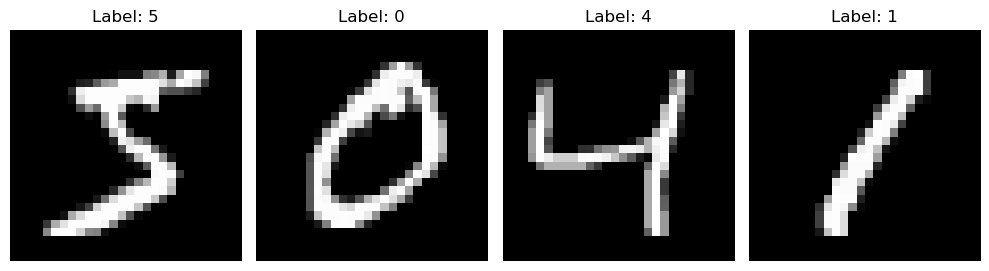

Input data reshaped to 2D (n x 28 x 28 -> n x 784)
X_train: (60000, 784)
Y_train: (60000,)
X_test:  (10000, 784)
Y_test:  (10000,)


In [8]:
# https://www.geeksforgeeks.org/machine-learning/mnist-dataset/

from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load data
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# Normalise data to over [0, 1] interval (uint8 -> float 64)
train_X = train_X / 255.0
test_X = test_X / 255.0

# Test imported data and show sample images
print("Shapes of imported data:")
print(f"X_train: {str(train_X.shape)}")
print(f"Y_train: {str(train_y.shape)}")
print(f"X_test:  {str(test_X.shape)}")
print(f"Y_test:  {str(test_y.shape)}")
print() # Space

# Plot examples
print("Frist 4 examples from MINST dataset")
plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(train_X[i], cmap="gray")
    plt.title(f"Label: {train_y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Reshape input arrays from 3D to 2D
train_X = train_X.reshape(train_X.shape[0], -1)
test_X = test_X.reshape(test_X.shape[0], -1)

# Test imported data and show sample images
print("Input data reshaped to 2D (n x 28 x 28 -> n x 784)")
print(f"X_train: {str(train_X.shape)}")
print(f"Y_train: {str(train_y.shape)}")
print(f"X_test:  {str(test_X.shape)}")
print(f"Y_test:  {str(test_y.shape)}")

### One-hot encoding
One-hot encoding converts the true label (int value) into boolean array. In this case an array of size 10 where location 0 to 9 (i.e. array[0] to array[9]) corresponds to a value of 0 to 9.

This one-hot encoded true labels allows for easy comparison of the output layer which is also an array of size 10, where a value at array location 0 to 9 (i.e. array[0] to array[9]) corresponds to the likelihood of the image showing a value of 0 to 9.  

The method for encoding was copped from here ([link](https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/)) where the author used a cool broadcasting to create the boolean matrix.

In [9]:
# One-hot encoding
def one_hot_encoding(label_data, dimension=10):
    # Use broadcasting to create boolean comparison matrix
    # https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/
    one_hot_labels = label_data[..., None] == np.arange(dimension)[None]
    return one_hot_labels.astype(np.float64)

one_hot_train_y = one_hot_encoding(train_y)
one_hot_test_y = one_hot_encoding(test_y)

print("Check data type:")
print(f"The data type of training labels: {one_hot_train_y.dtype}")
print(f"The data type of test labels: {one_hot_test_y.dtype}")
print()

print("Shape of one-hot encoded training and test arrays")
print(f"one_hot_train_y: {str(one_hot_train_y.shape)}")
print(f"one_hot_test_y: {str(one_hot_test_y.shape)}")
print()

print("Comparison of one-hot array to true labels:")
print(f"one-hot array: {one_hot_train_y[0]} -> true label: {train_y[0]}")
print(f"one-hot array: {one_hot_train_y[1]} -> true label: {train_y[1]}")
print(f"one-hot array: {one_hot_train_y[2]} -> true label: {train_y[2]}")

Check data type:
The data type of training labels: float64
The data type of test labels: float64

Shape of one-hot encoded training and test arrays
one_hot_train_y: (60000, 10)
one_hot_test_y: (10000, 10)

Comparison of one-hot array to true labels:
one-hot array: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] -> true label: 5
one-hot array: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.] -> true label: 0
one-hot array: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] -> true label: 4


## Activation functions
The ReLU (rectified linear unit) is a simple activation function that outputs 0 for negative values and maintains any positive value. This introducing non-linearity in a computationally efficient manner. Also, the derivative is simply 0 or 1 for negative and positive values respectively.

Softmax converts the layer into a probability distribution, which is great for classification problems like the MINST dataset. In this case the derivative can be estimated from the error (= predicted_y - true_y),

In [10]:
#################################################################
# Activation functions
#
# z: vector/array of nodes in Layer
#
#################################################################

# ReLU
def relu(z):
    return np.maximum(0, z)

def relu_deriv(output):
    return output > 0

# Softmax
def softmax(z):
    return np.exp(z)/sum(np.exp(z))

def softmax_deriv(predicted_y, true_y):
    # dL/dz = y_prediction - y_true
    # dL/dz = Softmax output - one-hot encoded vector
    return predicted_y - true_y

## Propagation
The information/data moves forward through the network by the data being multiple by the weight plus bias. Then the activation function is applied. The backward propagation follows the chain rule, calculating the gradients/error that each node needs to be modified in order to improve predictions. Finally the weights and bias is updated based on learning rate (compromise of convergence accuracy and training speed).

In [11]:

#################################################################
# Forward and backward propagation functions                    
#
#   w:      weights applied to Layer                                    
#   b:      bias applied to Layer                               
#   z:      propagation of layer forward before activation      
#   a:      propagated layer after activation                   
#   dz:     Gradient of z                                       
#   dw:     Change in weighting before learning rate applied    
#   db:     Change in bias before learning rate applied         
#   alpha:  Learning rate            
#                            
#################################################################

def forward(w1, b1, w2, b2, X):
    z1 = w1.dot(X) + b1     # Image data into Layer 1
    a1 = relu(z1)           # Relu activation of Layer 1
    z2 = w2.dot(a1) + b2    # Layer 1 output into Layer 2
    a2 = softmax(z2)        # Softmax on Layer 2
    return z1, a1, z2, a2

# Back propagation
def back_prop(z1, a1, a2, w2, X, Y):
	dz2 = softmax_deriv(a2, Y)              # Differentiate loss function
	dw2 = dz2.dot(a1.T)                     # New weight based on gradient (before learning rate)
	db2 = np.sum(dz2)                       # New weight as sum of gradient
	dz1 = relu_deriv(z1) * w2.T.dot(dz2)    # Differentiate layer 1, includes propagation from Layer 2 
	dw1 = dz1.dot(X.T)                      # New weight based on gradient (before learning rate)
	db1 = np.sum(dz1)                       # New weight as sum of gradient
	return dw1, db1, dw2, db2

# Update parameters
def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
    w1 -= alpha * dw1
    b1 -= alpha * db1
    w2 -= alpha * dw2
    b2 -= alpha * db2
    return w1, b1, w2, b2


### Loss function
The Categorical Cross-Entropy (CCE) is standard function to measure performance in classification models. It requires an input of probability distribution (which we get from  the softmax function) and calculates the difference from predicted distribution and true distribution (one-hot label). Note: the log function stretches the predicted distribution resulting in the difference in value being exaggerated.

In [ ]:
# Loss function
def cat_cross_entropy(one_hot_Y, a2, noSamples):
    CCE = -np.sum(one_hot_Y * np.log(a2)) * 1/(noSamples)
    return CCE

## Implementation
The following trains the neural network by iterating over the training dataset, this is repeated `epochs` times. Accuracy is measured as the % of correct predictions and loss is calculated using the CCE function.

In [15]:
# Hyperparameters
learning_rate = 0.005
epochs = 30
hidden_size = 64
pixels_per_image = 784  # 28 x 28
num_labels = 10         # 0 to 9

# Initial guess of weights & bias
rng = np.random.default_rng(seed=67)
w1 = 0.2 * (rng.random((hidden_size, pixels_per_image)) - .5)
b1 = np.zeros((hidden_size, 1))
w2 = 0.2 * (rng.random((num_labels, hidden_size)) - .5)
b2 = np.zeros((num_labels, 1))

# Data store for plotting
data_train_loss = []
data_train_accuracy = []
data_test_loss = []
data_test_accuracy = []

# Loop epochs
for j in range(epochs):

    training_loss = 0.0
    training_accuracy = 0

    # Loop gradient descent
    for i in range(len(train_X)):

        # Add axis for to use np.dot in propagation
        X = train_X[i][:, np.newaxis]
        Y = one_hot_train_y[i][:, np.newaxis]

        # Iterate forward and back over network
        z1, a1, z2, a2 = forward(w1, b1, w2, b2, X)
        dw1, db1, dw2, db2 = back_prop(z1, a1, a2, w2, X, Y)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, learning_rate )
        
        # Calc. performance
        training_loss += cat_cross_entropy(Y, a2, len(train_X))
        training_accuracy += int(np.argmax(Y) == np.argmax(a2)) # Count

    training_accuracy = training_accuracy / len(train_X) # count -> %
    
    # Testing evaluation
    results = relu(test_X @ w1.T) @ w2.T    # Forward propagation, no Softmax
    results = np.exp(results) / (np.sum(np.exp(results), axis=1))[:, np.newaxis] # Softmax

    # Calc. performance
    loss = cat_cross_entropy(one_hot_test_y, results, len(test_X))
    acc = np.sum(np.argmax(results, axis=1) == np.argmax(one_hot_test_y, axis=1)) / len(test_X)
    
    if j % 10 == 0:  # Reduce output
        print(f"Iteration: {j}")
        print(f"Train Accuracy: {training_accuracy}")
        print(f"Train Loss:, {training_loss}")
        print(f"Test Accuracy:, {acc}")
        print(f"Test Loss: {loss}")
        print()

    # Update data stores for plotting
    data_test_loss.append(loss)
    data_test_accuracy.append(acc)
    data_train_loss.append(training_loss)
    data_train_accuracy.append(training_accuracy)


Iteration: 0
Train Accuracy: 0.9165
Train Loss:, 0.2897307544303922
Test Accuracy:, 0.9443
Test Loss: 0.19843662916130897

Iteration: 10
Train Accuracy: 0.9942333333333333
Train Loss:, 0.02557554299162193
Test Accuracy:, 0.9729
Test Loss: 0.09156306420245944

Iteration: 20
Train Accuracy: 0.9995166666666667
Train Loss:, 0.006141180021499561
Test Accuracy:, 0.975
Test Loss: 0.09153797648262545



Text(0, 0.5, 'Loss')

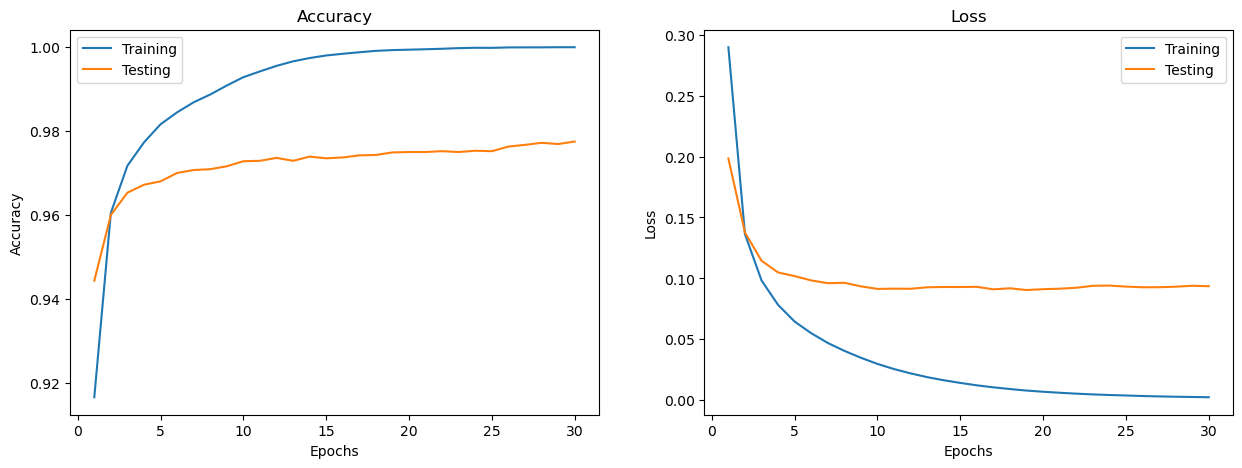

In [14]:
# Plotting
epochs_axis = np.arange(epochs) + 1

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axes[0].plot(epochs_axis, data_train_accuracy, label='Training')
axes[0].plot(epochs_axis, data_test_accuracy, label='Testing')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')

axes[1].plot(epochs_axis, data_train_loss, label='Training')
axes[1].plot(epochs_axis, data_test_loss, label='Testing')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')

<p style=\"text-align: center; font-style: italic; font-size: 14px\">
<b style=\"color: #d9230f\">Figure 1. Accuracy and loss of training and testing dataset.</b><br>
</p>

From the above it can be seen that:
* The training set at epoch 1 has a high accuracy - this is likely due to the large training set of 60K samples.
* Training accuracy increases and begins to plateaux around 20 epochs and the loss decreases in a nice profile.
* Testing accuracy increases at a steady rate with epochs and the loss plateaus about 15 epoch.